# Notebook by -
## Himel Sarder
## Email : info.himelcse@gmail.com

In [226]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

In [227]:
df = pd.read_csv('cinema_hall_ticket_sales.csv')

In [228]:
df.head()

,Ticket_ID,Age,Ticket_Price,Movie_Genre,Seat_Type,Number_of_Person,Purchase_Again
0,N4369,55,12.27,Comedy,Standard,7,No
1,B8091,35,19.02,Drama,Standard,Alone,Yes
2,V6341,55,22.52,Horror,VIP,3,No
3,B3243,53,23.01,Drama,Standard,6,Yes
4,I3814,30,21.81,Comedy,VIP,4,Yes


In [229]:
genre_counts

Movie_Genre
Action    310
Horror    299
Comedy    287
Drama     286
Sci-Fi    258
Name: count, dtype: int64

<Axes: xlabel='Movie_Genre'>

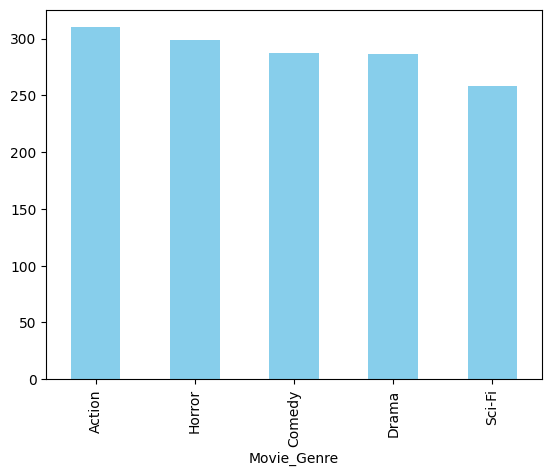

In [104]:
# Get the value counts of the 'Movie_Genre' column
genre_counts = df['Movie_Genre'].value_counts()

# Plot the results
genre_counts.plot(kind='bar', color='skyblue')

Text(0.5, 1.0, 'Seat Type')

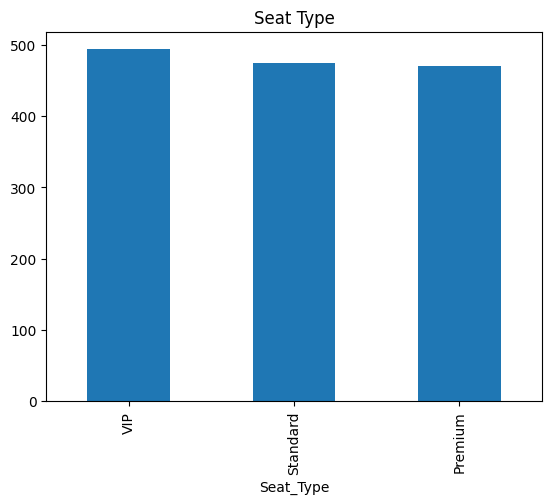

In [105]:
fig = df['Seat_Type'].value_counts().plot.bar()
fig.set_title('Seat Type')

In [106]:
# extract numerical part
df['number_numerical'] = pd.to_numeric(df["Number_of_Person"], errors='coerce', downcast='integer').fillna(1).astype(int)

In [107]:
# extract categorical part
df['number_categorical'] = np.where(df['Number_of_Person'] == 'Alone', 'Alone', 'Not Alone')

df.head()

,Ticket_ID,Age,Ticket_Price,Movie_Genre,Seat_Type,Number_of_Person,Purchase_Again,number_numerical,number_categorical
0,N4369,55,12.27,Comedy,Standard,7,No,7,Not Alone
1,B8091,35,19.02,Drama,Standard,Alone,Yes,1,Alone
2,V6341,55,22.52,Horror,VIP,3,No,3,Not Alone
3,B3243,53,23.01,Drama,Standard,6,Yes,6,Not Alone
4,I3814,30,21.81,Comedy,VIP,4,Yes,4,Not Alone


<Axes: xlabel='Purchase_Again'>

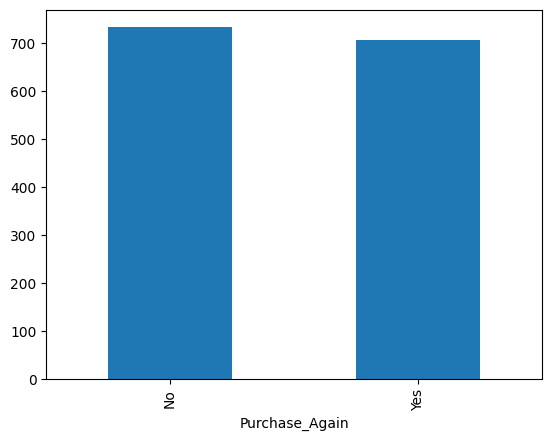

In [108]:
df['Purchase_Again'].value_counts().plot(kind='bar')

In [109]:
df['Ticket_num'] = df['Ticket_ID'].str.extract(r'(\d+)') # captures numerical part
df['Ticket_cat'] = df['Ticket_ID'].str[0] # captures the first letter

df.head()

,Ticket_ID,Age,Ticket_Price,Movie_Genre,Seat_Type,Number_of_Person,Purchase_Again,number_numerical,number_categorical,Ticket_num,Ticket_cat
0,N4369,55,12.27,Comedy,Standard,7,No,7,Not Alone,4369,N
1,B8091,35,19.02,Drama,Standard,Alone,Yes,1,Alone,8091,B
2,V6341,55,22.52,Horror,VIP,3,No,3,Not Alone,6341,V
3,B3243,53,23.01,Drama,Standard,6,Yes,6,Not Alone,3243,B
4,I3814,30,21.81,Comedy,VIP,4,Yes,4,Not Alone,3814,I


<Axes: xlabel='Ticket_cat'>

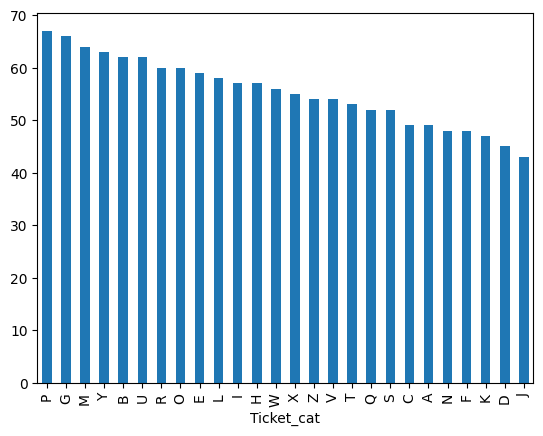

In [110]:
df['Ticket_cat'].value_counts().plot(kind='bar')

In [111]:
# extract the last bit of ticket as number
# df['ticket_num'] = df['Ticket_ID'].apply(lambda s: s.split()[-1])
# df['ticket_num'] = pd.to_numeric(df['ticket_num'], errors='coerce', downcast='integer')

# extract the first part of ticket as category
# df['ticket_cat'] = df['Ticket_ID'].apply(lambda s: s.split()[0])
# df['ticket_cat'] = np.where(df['ticket_cat'].str.isdigit(), np.nan, df['ticket_cat'])

# df.head(20)

In [112]:
# X will be the dataframe without the 'Purchase_Again' column
X = df.drop(['Purchase_Again', 'Number_of_Person', 'Ticket_num', 'Ticket_ID'], axis=1)

# y will be the 'Purchase_Again' column as the target variable
y = df['Purchase_Again']

In [113]:
X.head()

,Age,Ticket_Price,Movie_Genre,Seat_Type,number_numerical,number_categorical,Ticket_cat
0,55,12.27,Comedy,Standard,7,Not Alone,N
1,35,19.02,Drama,Standard,1,Alone,B
2,55,22.52,Horror,VIP,3,Not Alone,V
3,53,23.01,Drama,Standard,6,Not Alone,B
4,30,21.81,Comedy,VIP,4,Not Alone,I


In [114]:
df.isnull().sum()

Ticket_ID             0
Age                   0
Ticket_Price          0
Movie_Genre           0
Seat_Type             0
Number_of_Person      0
Purchase_Again        0
number_numerical      0
number_categorical    0
Ticket_num            0
Ticket_cat            0
dtype: int64

In [117]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=True)

In [118]:
X_train.head()

,Age,Ticket_Price,Movie_Genre,Seat_Type,number_numerical,number_categorical,Ticket_cat
135,52,11.95,Action,Premium,4,Not Alone,G
368,35,14.60,Sci-Fi,Standard,5,Not Alone,G
750,33,22.07,Drama,Standard,6,Not Alone,Y
801,26,21.15,Drama,Premium,1,Alone,Q
1322,26,17.78,Drama,Premium,1,Alone,C


In [163]:
X_train2 = pd.get_dummies(X_train, columns=['Movie_Genre','Ticket_cat'],drop_first=True, dtype=int)
X_train2.head()

,Age,Ticket_Price,Seat_Type,number_numerical,number_categorical,Movie_Genre_Comedy,Movie_Genre_Drama,Movie_Genre_Horror,Movie_Genre_Sci-Fi,Ticket_cat_B,...,Ticket_cat_Q,Ticket_cat_R,Ticket_cat_S,Ticket_cat_T,Ticket_cat_U,Ticket_cat_V,Ticket_cat_W,Ticket_cat_X,Ticket_cat_Y,Ticket_cat_Z
135,52,11.95,Premium,4,Not Alone,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
368,35,14.60,Standard,5,Not Alone,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
750,33,22.07,Standard,6,Not Alone,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
801,26,21.15,Premium,1,Alone,0,1,0,0,0,...,1,0,0,0,0,0,0,0,0,0
1322,26,17.78,Premium,1,Alone,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [164]:
X_test2 = pd.get_dummies(X_test, columns=['Movie_Genre', 'Ticket_cat'], drop_first=True, dtype=int)

In [167]:
X_test2.head()

,Age,Ticket_Price,Seat_Type,number_numerical,number_categorical,Movie_Genre_Comedy,Movie_Genre_Drama,Movie_Genre_Horror,Movie_Genre_Sci-Fi,Ticket_cat_B,...,Ticket_cat_Q,Ticket_cat_R,Ticket_cat_S,Ticket_cat_T,Ticket_cat_U,Ticket_cat_V,Ticket_cat_W,Ticket_cat_X,Ticket_cat_Y,Ticket_cat_Z
1188,58,14.30,Standard,1,Alone,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
330,33,19.49,Standard,1,Alone,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
757,24,13.68,Premium,1,Alone,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
53,57,13.62,Premium,3,Not Alone,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
833,37,15.67,Premium,1,Alone,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [168]:
seat_type_order = [['Standard', 'Premium', 'VIP']]

In [169]:
oe = OrdinalEncoder(categories=seat_type_order)

In [170]:
# Fit and transform X_train
X_train2['Seat_Type'] = oe.fit_transform(X_train[['Seat_Type']])

In [176]:
# Transform X_test 
X_test2['Seat_Type'] = oe.transform(X_test[['Seat_Type']])

In [177]:
X_train2.sample(10)

,Age,Ticket_Price,Seat_Type,number_numerical,number_categorical,Movie_Genre_Comedy,Movie_Genre_Drama,Movie_Genre_Horror,Movie_Genre_Sci-Fi,Ticket_cat_B,...,Ticket_cat_Q,Ticket_cat_R,Ticket_cat_S,Ticket_cat_T,Ticket_cat_U,Ticket_cat_V,Ticket_cat_W,Ticket_cat_X,Ticket_cat_Y,Ticket_cat_Z
361,35,10.98,1.0,1,Alone,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1043,41,17.78,0.0,1,Alone,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,30,21.81,2.0,4,Not Alone,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1084,24,18.22,0.0,1,Alone,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1100,35,10.57,1.0,1,Alone,0,0,0,1,0,...,0,0,1,0,0,0,0,0,0,0
117,40,13.20,2.0,2,Not Alone,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
538,25,21.96,2.0,6,Not Alone,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
440,58,13.52,2.0,3,Not Alone,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1107,39,20.16,0.0,2,Not Alone,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
54,54,19.01,2.0,2,Not Alone,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [178]:
# Initialize LabelEncoder
le = LabelEncoder()

In [180]:
# Fit and transform X_train2
X_train2['number_categorical'] = le.fit_transform(X_train2['number_categorical'])

In [181]:
X_train2.head()

,Age,Ticket_Price,Seat_Type,number_numerical,number_categorical,Movie_Genre_Comedy,Movie_Genre_Drama,Movie_Genre_Horror,Movie_Genre_Sci-Fi,Ticket_cat_B,...,Ticket_cat_Q,Ticket_cat_R,Ticket_cat_S,Ticket_cat_T,Ticket_cat_U,Ticket_cat_V,Ticket_cat_W,Ticket_cat_X,Ticket_cat_Y,Ticket_cat_Z
135,52,11.95,1.0,4,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
368,35,14.60,0.0,5,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
750,33,22.07,0.0,6,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
801,26,21.15,1.0,1,0,0,1,0,0,0,...,1,0,0,0,0,0,0,0,0,0
1322,26,17.78,1.0,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [183]:
# Transform X_test2
X_test2['number_categorical'] = le.transform(X_test2['number_categorical'])
X_test2.shape

(288, 34)

In [189]:
y_train.head()

135     Yes
368      No
750      No
801      No
1322     No
Name: Purchase_Again, dtype: object

In [191]:
# Fit and transform y_train
y_train = le.fit_transform(y_train)

In [192]:
y_train

array([1, 0, 0, ..., 1, 0, 0])

In [194]:
# Transform y_test
y_test = le.transform(y_test)

# Model

## Logistic Regression

In [195]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [196]:
# Initialize Logistic Regression model
logreg = LogisticRegression(random_state=42)

In [197]:
# Train the model
logreg.fit(X_train2, y_train)

LogisticRegression(random_state=42)

In [198]:
# Make predictions
y_pred = logreg.predict(X_test2)

In [199]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

# Print results
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", report)

Accuracy: 0.5069
Classification Report:
               precision    recall  f1-score   support

           0       0.51      0.51      0.51       146
           1       0.50      0.50      0.50       142

    accuracy                           0.51       288
   macro avg       0.51      0.51      0.51       288
weighted avg       0.51      0.51      0.51       288



In [200]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train2_scaled = scaler.fit_transform(X_train2)
X_test2_scaled = scaler.transform(X_test2)

In [201]:
logreg.fit(X_train2_scaled, y_train)

LogisticRegression(random_state=42)

In [203]:
y_pred1 = logreg.predict(X_test2_scaled)

In [204]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred1)
report = classification_report(y_test, y_pred1)

# Print results
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", report)

Accuracy: 0.4826
Classification Report:
               precision    recall  f1-score   support

           0       0.49      0.47      0.48       146
           1       0.48      0.49      0.48       142

    accuracy                           0.48       288
   macro avg       0.48      0.48      0.48       288
weighted avg       0.48      0.48      0.48       288



In [205]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, interaction_only=True)
X_train_poly = poly.fit_transform(X_train2_scaled)
X_test_poly = poly.transform(X_test2_scaled)

logreg.fit(X_train_poly, y_train)

LogisticRegression(random_state=42)

In [208]:
y_pred2 = logreg.predict(X_test_poly)

In [209]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred2)
report = classification_report(y_test, y_pred2)

# Print results
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", report)

Accuracy: 0.4896
Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.57      0.53       146
           1       0.48      0.41      0.44       142

    accuracy                           0.49       288
   macro avg       0.49      0.49      0.49       288
weighted avg       0.49      0.49      0.49       288



In [213]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train2, y_train)
y_pred_rf = rf.predict(X_test2)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

Accuracy: 0.5208333333333334


In [214]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300], 
    'max_depth': [5, 10, 20], 
    'min_samples_split': [2, 5, 10]
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train2, y_train)

print("Best Parameters:", grid_search.best_params_)
best_rf = grid_search.best_estimator_
y_pred_rf = best_rf.predict(X_test2)

print("Optimized Accuracy:", accuracy_score(y_test, y_pred_rf))

Best Parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 300}
Optimized Accuracy: 0.5069444444444444


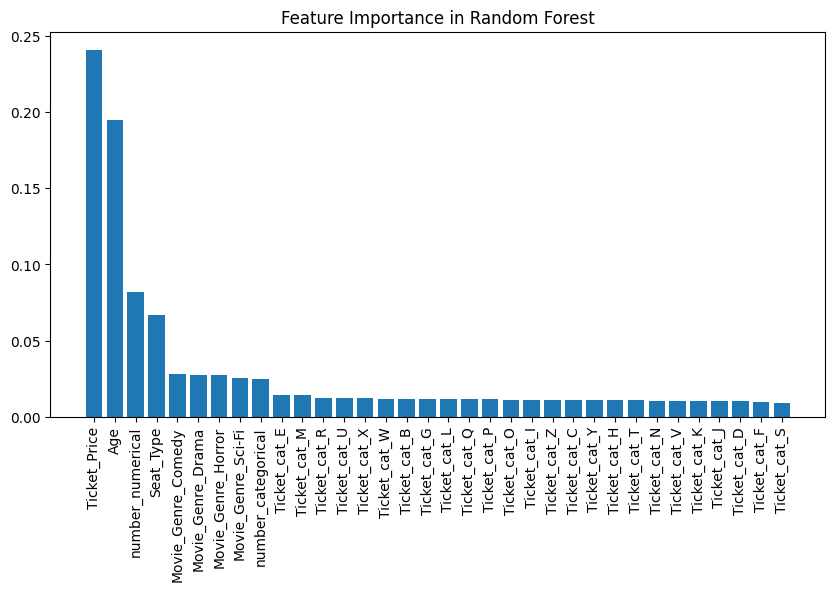

In [215]:
import matplotlib.pyplot as plt
import numpy as np

feature_importances = best_rf.feature_importances_
sorted_idx = np.argsort(feature_importances)[::-1]

plt.figure(figsize=(10,5))
plt.bar(range(X_train2.shape[1]), feature_importances[sorted_idx])
plt.xticks(range(X_train2.shape[1]), X_train2.columns[sorted_idx], rotation=90)
plt.title("Feature Importance in Random Forest")
plt.show()


In [216]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42)
xgb.fit(X_train2, y_train)

y_pred_xgb = xgb.predict(X_test2)
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

XGBoost Accuracy: 0.5347222222222222


In [217]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
selector = RFE(rf, n_features_to_select=10)  # Select top 10 features
selector.fit(X_train2, y_train)

selected_features = X_train2.columns[selector.support_]
print("Selected Features:", selected_features)

Selected Features: Index(['Age', 'Ticket_Price', 'Seat_Type', 'number_numerical',
       'number_categorical', 'Movie_Genre_Comedy', 'Movie_Genre_Drama',
       'Movie_Genre_Horror', 'Movie_Genre_Sci-Fi', 'Ticket_cat_M'],
      dtype='object')


In [218]:
from xgboost import XGBClassifier
xgb = XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42)
xgb.fit(X_train2[selected_features], y_train)
y_pred_xgb = xgb.predict(X_test2[selected_features])

In [219]:
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

XGBoost Accuracy: 0.5138888888888888


In [220]:
# Initialize and train the Logistic Regression model
log_reg = LogisticRegression(max_iter=500, random_state=42)
log_reg.fit(X_train2[selected_features], y_train)

# Predict on test data
y_pred_log = log_reg.predict(X_test2[selected_features])

# Evaluate performance
accuracy_log = accuracy_score(y_test, y_pred_log)
print(f"Logistic Regression Accuracy: {accuracy_log:.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.5521
Classification Report:
               precision    recall  f1-score   support

           0       0.55      0.63      0.59       146
           1       0.55      0.47      0.51       142

    accuracy                           0.55       288
   macro avg       0.55      0.55      0.55       288
weighted avg       0.55      0.55      0.55       288



In [222]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
selector = RFE(rf, n_features_to_select=4)  # Select top 10 features
selector.fit(X_train2, y_train)

selected_features = X_train2.columns[selector.support_]
print("Selected Features:", selected_features)

Selected Features: Index(['Age', 'Ticket_Price', 'Seat_Type', 'number_numerical'], dtype='object')


In [223]:
from xgboost import XGBClassifier
xgb = XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42)
xgb.fit(X_train2[selected_features], y_train)
y_pred_xgb = xgb.predict(X_test2[selected_features])

In [224]:
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

XGBoost Accuracy: 0.5034722222222222


In [225]:
# Initialize and train the Logistic Regression model
log_reg = LogisticRegression(max_iter=500, random_state=42)
log_reg.fit(X_train2[selected_features], y_train)

# Predict on test data
y_pred_log = log_reg.predict(X_test2[selected_features])

# Evaluate performance
accuracy_log = accuracy_score(y_test, y_pred_log)
print(f"Logistic Regression Accuracy: {accuracy_log:.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.5590
Classification Report:
               precision    recall  f1-score   support

           0       0.55      0.68      0.61       146
           1       0.57      0.43      0.49       142

    accuracy                           0.56       288
   macro avg       0.56      0.56      0.55       288
weighted avg       0.56      0.56      0.55       288

